In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 600
brands = np.random.choice(["Toyota","Honda","Ford","BMW","Hyundai"], n, p=[0.25,0.22,0.2,0.13,0.2])
brand_premium = {"Toyota":0, "Honda":500, "Ford":-500, "BMW":8000, "Hyundai":-1000}

age = np.random.uniform(0, 15, n)
mileage = age * np.random.uniform(8000, 16000, n)
engine = np.random.uniform(1.0, 4.0, n)

fuel = np.random.choice(["Petrol","Diesel","Electric"], n, p=[0.5,0.35,0.15])
fuel_premium = np.where(fuel=="Electric", 4000, np.where(fuel=="Diesel", 800, 0))

base_price = 28000 - age*1400 - mileage*0.04 + engine*1500
price = base_price + np.array([brand_premium[b] for b in brands]) + fuel_premium \
        + np.random.normal(0, 1200, n)
price = np.clip(price, 1500, None)

veh_df = pd.DataFrame({
    "brand": brands, "age_years": age, "mileage_km": mileage,
    "engine_size_L": engine, "fuel_type": fuel, "price": price
})

veh_df.head()

,brand,age_years,mileage_km,engine_size_L,fuel_type,price
0,Honda,2.534026,35643.876468,3.869504,Petrol,30602.788570
1,Hyundai,4.178855,34252.801971,3.212525,Petrol,25338.685559
2,BMW,2.655157,21711.190182,2.059754,Petrol,35324.246749
3,Ford,1.330538,14088.909617,1.889607,Petrol,26268.953669
4,Toyota,1.809538,21550.052164,2.049110,Diesel,29932.641937


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

num_feats = ["age_years", "mileage_km", "engine_size_L"]
cat_feats = ["brand", "fuel_type"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
])

X = veh_df.drop(columns=["price"])
y = veh_df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocessing object built. Train size:", len(X_train), "| Test size:", len(X_test))

Preprocessing object built. Train size: 480 | Test size: 120


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = {}
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds)
    }
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).T.round(2)
results_df

,MAE,RMSE,R2
Linear Regression,935.27,1154.62,0.98
Random Forest,1106.23,1462.22,0.97
Gradient Boosting,1042.51,1323.04,0.98


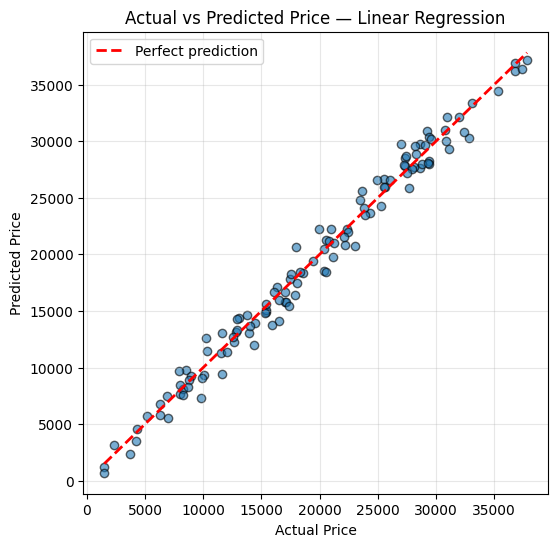

Best model selected automatically: Linear Regression


In [ ]:
best_name = results_df["RMSE"].idxmin()
best_pipe = fitted_pipes[best_name]
preds = best_pipe.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price — {best_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best model selected automatically: {best_name}")